In [22]:
# Import TensorFlow and Keras tools for deep learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Import pretrained MobileNetV2 architecture
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Import plotting library
import matplotlib.pyplot as plt

# Path helps manage dataset paths
from pathlib import Path

In [23]:
# Define dataset paths
train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

# Standard image size for MobileNetV2
IMG_SIZE = (224, 224)

# Keep batch size small to avoid file-loading/memory issues
BATCH_SIZE = 8

# Seed keeps training/validation split reproducible
SEED = 42

# Number of training epochs
EPOCHS = 10

In [24]:
# Load training dataset with validation split
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load testing dataset separately
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Store class names
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 5524 files belonging to 4 classes.
Using 4420 files for training.
Found 5524 files belonging to 4 classes.
Using 1104 files for validation.
Found 554 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [25]:
# Data augmentation creates modified versions of training images
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

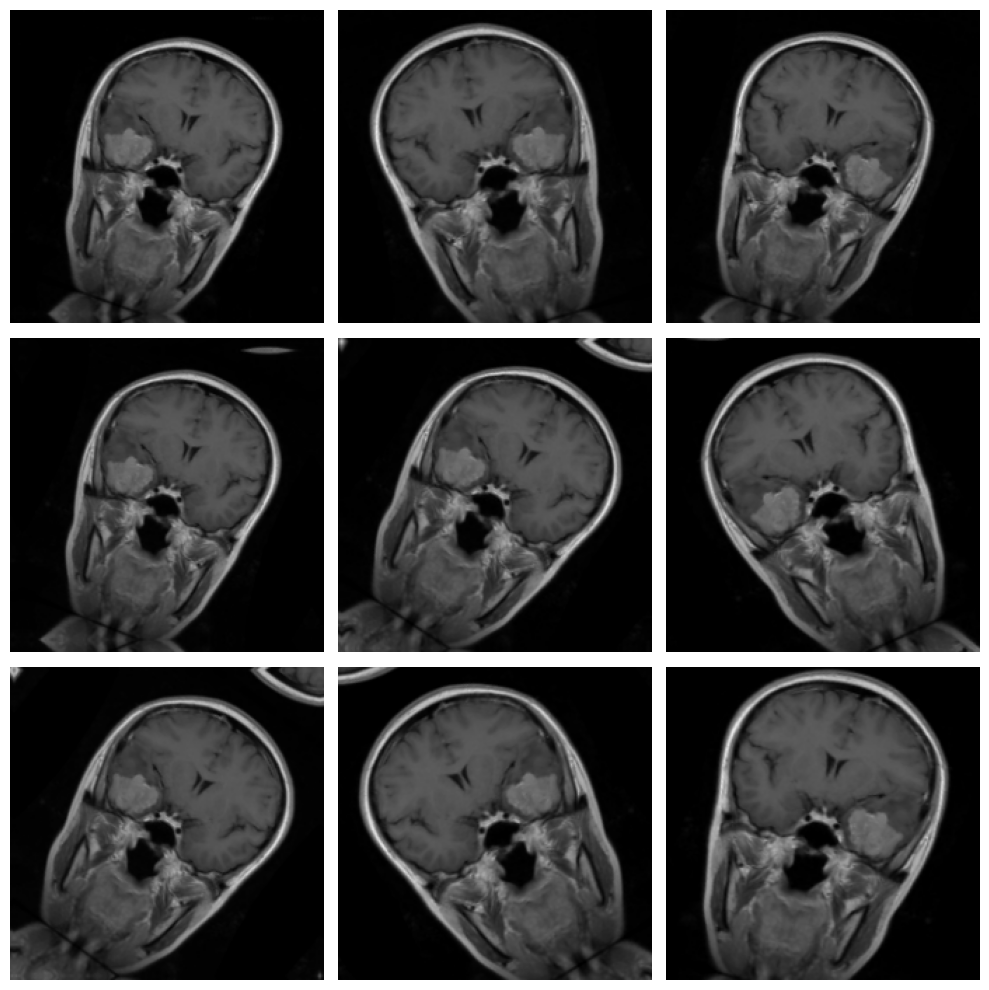

In [26]:
# Visualize augmented versions of one MRI image
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    first_image = images[0]
    
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"), cmap="gray")
        plt.axis("off")

plt.tight_layout()
plt.savefig("../figures/augmentation_examples.png", dpi=300)
plt.show()

In [27]:
# Apply MobileNet preprocessing AFTER augmentation later in the model
# Do NOT preprocess datasets directly here

train_ds_prepared = train_ds
val_ds_prepared = val_ds
test_ds_prepared = test_ds

In [28]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
# Configure model training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS
)

Epoch 1/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.5161 - loss: 1.1425 - val_accuracy: 0.7582 - val_loss: 0.7169
Epoch 2/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.7262 - loss: 0.7218 - val_accuracy: 0.8080 - val_loss: 0.5640
Epoch 3/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7857 - loss: 0.5759 - val_accuracy: 0.8143 - val_loss: 0.5083
Epoch 4/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.8075 - loss: 0.5278 - val_accuracy: 0.8388 - val_loss: 0.4669
Epoch 5/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8213 - loss: 0.4813 - val_accuracy: 0.8397 - val_loss: 0.4387
Epoch 6/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 52s 93ms/step - accuracy: 0.8376 - loss: 0.4515 - val_accuracy: 0.8406 - val_loss: 0.4317
Epoch 7/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.8403 - loss: 0.4373 - val_accuracy: 0.8424 - val_loss: 0.4188
Epoch 8/10
553/553 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.8468 - loss: 0.4087 - 

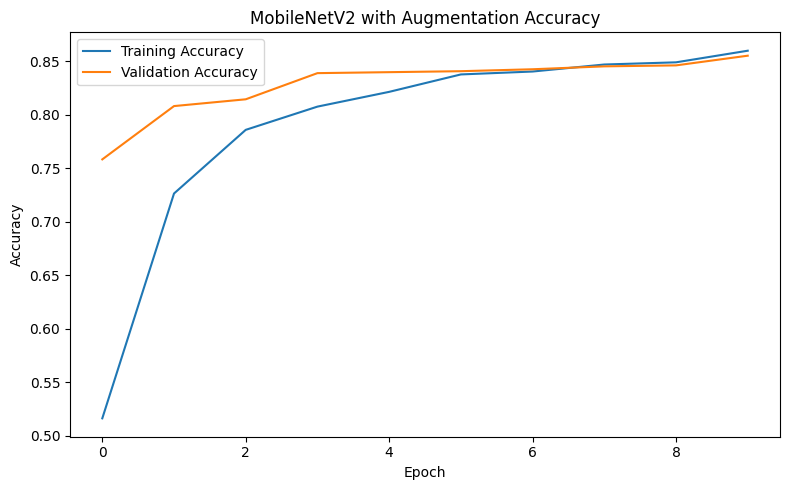

In [31]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("MobileNetV2 with Augmentation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/mobilenet_aug_accuracy.png", dpi=300)
plt.show()

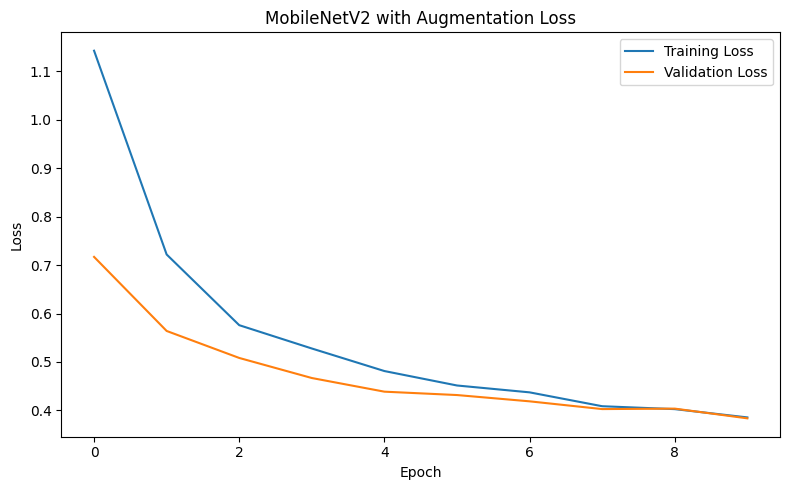

In [32]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 with Augmentation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/mobilenet_aug_loss.png", dpi=300)
plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(test_ds_prepared)

print("MobileNetV2 with Augmentation Test Loss:", test_loss)
print("MobileNetV2 with Augmentation Test Accuracy:", test_accuracy)

70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8682 - loss: 0.3608
MobileNetV2 with Augmentation Test Loss: 0.36075642704963684
MobileNetV2 with Augmentation Test Accuracy: 0.8682310581207275


In [35]:
# Save augmented MobileNetV2 model
model.save("../models/mobilenetv2_augmented_model.keras")

## Augmentation Experiment Summary

This notebook tested whether data augmentation improves MobileNetV2 performance on brain MRI tumor classification. Augmentation was applied only to the training images using random flipping, rotation, zoom, and contrast changes. The augmented MobileNetV2 model will be compared against the non-augmented MobileNetV2 model to analyze whether augmentation improves generalization performance.
